In [44]:
import pandas as pd
from glob import glob

import librosa.display
from pydub import AudioSegment
import numpy as np

In [2]:
audio_files_m4a = glob('/Users/d0304693/Documents/fun/als-voice-cloning-evaluation/data/m4a/*.m4a')
print(len(audio_files_m4a))

42


/var/folders/h9/hvhggy7d0dq_2zmy_gbx1n_r0000gp/T/ipykernel_61077/1267432642.py:1: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_files_m4a[5])
/Users/d0304693/Library/Python/3.13/lib/python/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


<Axes: title={'center': 'Audio Signal'}>

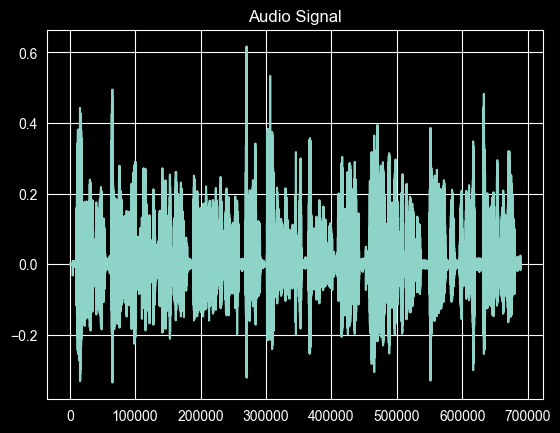

In [12]:
y, sr = librosa.load(audio_files_m4a[5])
pd.Series(y).plot(title='Audio Signal')

In [15]:
print(f'Shape of audio signal: {y.shape}')

Shape of audio signal: (689283,)
Sample rate: [-1.6656710e-07  1.9602591e-07 -2.1156211e-07 ... -1.6319824e-03
 -5.5531075e-04  1.9173625e-05] Hz


In [3]:
data_frame_m4a = []

In [19]:
for f in audio_files_m4a:
    y, sr = librosa.load(f)
    data_frame_m4a.append({
        'file': f,
        'duration_s': librosa.get_duration(y=y, sr=sr),
        'sample_rate': sr,
        'num_samples': len(y),
        'file_format': f.split('.')[-1],
    })
df = pd.DataFrame(data_frame_m4a)

/var/folders/h9/hvhggy7d0dq_2zmy_gbx1n_r0000gp/T/ipykernel_61077/240927522.py:2: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(f)


In [20]:
df

,file,duration_s,sample_rate,num_samples,file_format
0,/Users/d0304693/Documents/fun/als-voice-clonin...,38.82,22050,855981,m4a
1,/Users/d0304693/Documents/fun/als-voice-clonin...,41.94,22050,924777,m4a
2,/Users/d0304693/Documents/fun/als-voice-clonin...,93.06,22050,2051973,m4a
3,/Users/d0304693/Documents/fun/als-voice-clonin...,15.22,22050,335601,m4a
4,/Users/d0304693/Documents/fun/als-voice-clonin...,15.64,22050,344862,m4a
...,...,...,...,...,...
79,/Users/d0304693/Documents/fun/als-voice-clonin...,46.34,22050,1021797,m4a
80,/Users/d0304693/Documents/fun/als-voice-clonin...,25.20,22050,555660,m4a
81,/Users/d0304693/Documents/fun/als-voice-clonin...,41.70,22050,919485,m4a
82,/Users/d0304693/Documents/fun/als-voice-clonin...,21.90,22050,482895,m4a


In [21]:
df.describe()

,duration_s,sample_rate,num_samples
count,84.000000,84.0,8.400000e+01
mean,44.240476,22050.0,9.755025e+05
std,28.762368,0.0,6.342102e+05
min,13.820000,22050.0,3.047310e+05
25%,23.620000,22050.0,5.208210e+05
50%,38.480000,22050.0,8.484840e+05
75%,51.300000,22050.0,1.131165e+06
max,152.600000,22050.0,3.364830e+06


### Convert to .wav format

In [ ]:
for f in audio_files_m4a:
    base_file_name = f.split('/')[-1].split('.')[0]
    audio = AudioSegment.from_file(f, format='m4a')
    audio.export(f'data/wav/{base_file_name}.wav', format='wav')

### Signal Analysis


In [45]:
audio_files_wav = glob('/Users/d0304693/Documents/fun/als-voice-cloning-evaluation/data/wav/*.wav')
print(len(audio_files_m4a))

42


In [46]:
data_frame_wav = []
for f in audio_files_wav:
    y, sr = librosa.load(f)
    data_frame_wav.append({
        'file': f,
        'duration_s': librosa.get_duration(y=y, sr=sr),
        'sample_rate': sr,
        'num_samples': len(y),
        'file_format': f.split('.')[-1],
    })
df = pd.DataFrame(data_frame_wav)

In [47]:
peaks = []
for f in audio_files_wav:
    y, sr = librosa.load(f)
    peak = np.max(np.abs(y))
    peaks.append(peak)
df['peak_amplitude'] = peaks

<Axes: >

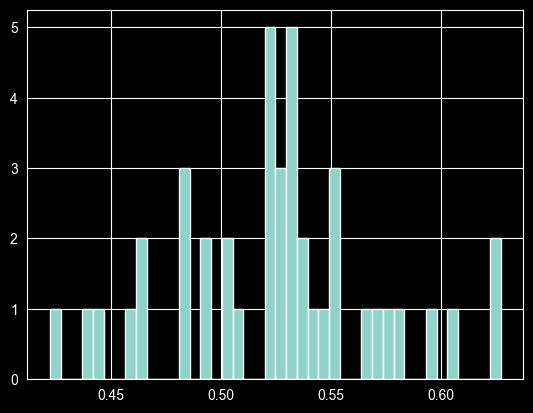

In [49]:
df['peak_amplitude'].hist(bins = 42)